# Car Accident Analysis — Weather, Climate & Population


In [2]:
# 1. Setup (local / VS Code). Installs into the active kernel; run once.
%pip -q install pandas numpy matplotlib seaborn scipy statsmodels plotly kaleido kaggle
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, glob, os
import matplotlib.pyplot as plt, seaborn as sns
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
sns.set_theme(style="whitegrid"); os.makedirs("figs", exist_ok=True)
print("Setup OK")

Note: you may need to restart the kernel to use updated packages.
Setup OK


In [3]:
# 2. Download accidents dataset from Kaggle (local)
# ONE-TIME AUTH: place kaggle.json at  ~/.kaggle/kaggle.json  (mac/Linux)
#   or  C:\Users\<you>\.kaggle\kaggle.json  (Windows).
#   mac/Linux also run in a terminal:  chmod 600 ~/.kaggle/kaggle.json
# Get the token: kaggle.com -> profile -> Settings -> Create New API Token.
# Needs ~3 GB free disk. Downloads + unzips into ./data
import kaggle
kaggle.api.dataset_download_files("sobhanmoosavi/us-accidents", path="./data", unzip=True)
import glob; print(glob.glob("./data/*.csv"))

Dataset URL: https://www.kaggle.com/datasets/sobhanmoosavi/us-accidents
['./data/US_Accidents_March23.csv']


In [4]:
# 3. Load + first look
path = glob.glob('./data/US_Accidents*.csv')[0]
want = ['Severity','Start_Time','State','County','Start_Lat','Start_Lng',
        'Weather_Condition','Temperature(F)','Visibility(mi)','Precipitation(in)','Humidity(%)']
allcols = pd.read_csv(path, nrows=5).columns.tolist()
use = [c for c in want if c in allcols]
print("File columns:", allcols); print("Using:", use)
df = pd.read_csv(path, usecols=use)
print(">> REPORT NUMBER total rows:", f"{len(df):,}")
df.head()

File columns: ['ID', 'Source', 'Severity', 'Start_Time', 'End_Time', 'Start_Lat', 'Start_Lng', 'End_Lat', 'End_Lng', 'Distance(mi)', 'Description', 'Street', 'City', 'County', 'State', 'Zipcode', 'Country', 'Timezone', 'Airport_Code', 'Weather_Timestamp', 'Temperature(F)', 'Wind_Chill(F)', 'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Direction', 'Wind_Speed(mph)', 'Precipitation(in)', 'Weather_Condition', 'Amenity', 'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway', 'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal', 'Turning_Loop', 'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight', 'Astronomical_Twilight']
Using: ['Severity', 'Start_Time', 'State', 'County', 'Start_Lat', 'Start_Lng', 'Weather_Condition', 'Temperature(F)', 'Visibility(mi)', 'Precipitation(in)', 'Humidity(%)']
>> REPORT NUMBER total rows: 7,728,394


,Severity,Start_Time,Start_Lat,Start_Lng,County,State,Temperature(F),Humidity(%),Visibility(mi),Precipitation(in),Weather_Condition
0,3,2016-02-08 05:46:00,39.865147,-84.058723,Montgomery,OH,36.9,91.0,10.0,0.02,Light Rain
1,2,2016-02-08 06:07:59,39.928059,-82.831184,Franklin,OH,37.9,100.0,10.0,0.00,Light Rain
2,2,2016-02-08 06:49:27,39.063148,-84.032608,Clermont,OH,36.0,100.0,10.0,NaN,Overcast
3,3,2016-02-08 07:23:34,39.747753,-84.205582,Montgomery,OH,35.1,96.0,9.0,NaN,Mostly Cloudy
4,2,2016-02-08 07:39:07,39.627781,-84.188354,Montgomery,OH,36.0,89.0,6.0,NaN,Mostly Cloudy


In [5]:
# 4. Clean + feature engineering
df['Start_Time'] = pd.to_datetime(df['Start_Time'], errors='coerce')
df = df.dropna(subset=['Start_Time','State','Severity'])
df['year']  = df['Start_Time'].dt.year
df['month'] = df['Start_Time'].dt.month
df['hour']  = df['Start_Time'].dt.hour
df['ym']    = df['Start_Time'].dt.to_period('M').astype(str)

def weather_bucket(w):
    if not isinstance(w, str): return 'Unknown'
    s = w.lower()
    if any(k in s for k in ['thunder','t-storm','squall']): return 'Thunderstorm'
    if any(k in s for k in ['snow','sleet','wintry','ice','hail','freezing']): return 'Snow/Ice'
    if any(k in s for k in ['rain','drizzle','shower']): return 'Rain'
    if any(k in s for k in ['fog','mist','haze','smoke']): return 'Fog/Low-vis'
    if any(k in s for k in ['cloud','overcast']): return 'Cloudy'
    if any(k in s for k in ['clear','fair','sunny']): return 'Clear'
    if 'wind' in s: return 'Windy'
    return 'Other'
df['weather'] = df['Weather_Condition'].apply(weather_bucket) if 'Weather_Condition' in df else 'Unknown'
print(">> REPORT NUMBER years covered:", sorted(df['year'].dropna().unique().astype(int)))
print(df['weather'].value_counts())

>> REPORT NUMBER years covered: [2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023]
weather
Clear           3044607
Cloudy          2899282
Rain             466748
Fog/Low-vis      182997
Unknown          155462
Snow/Ice         155237
Thunderstorm      77545
Other              3042
Windy               308
Name: count, dtype: int64


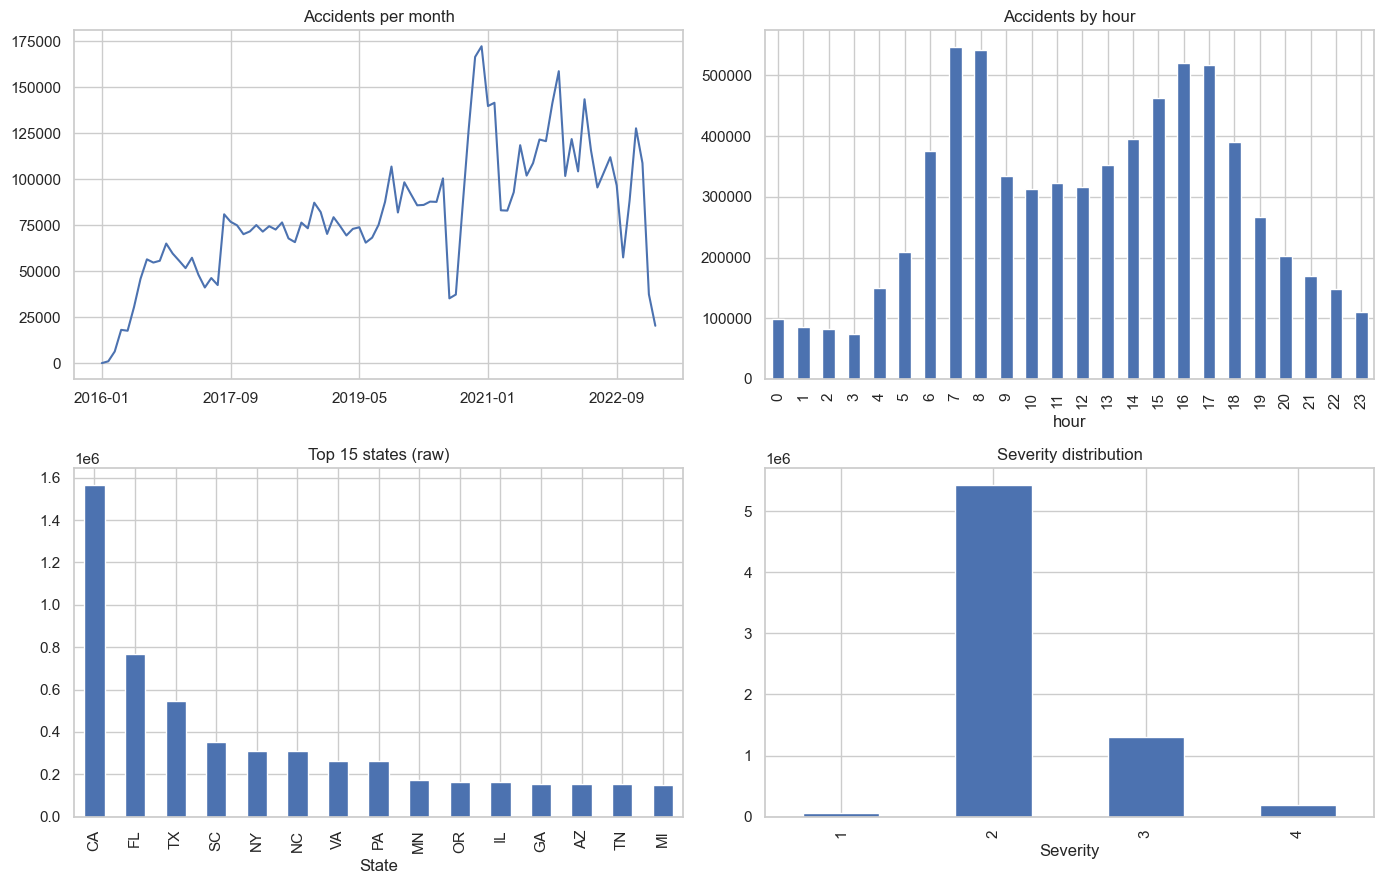

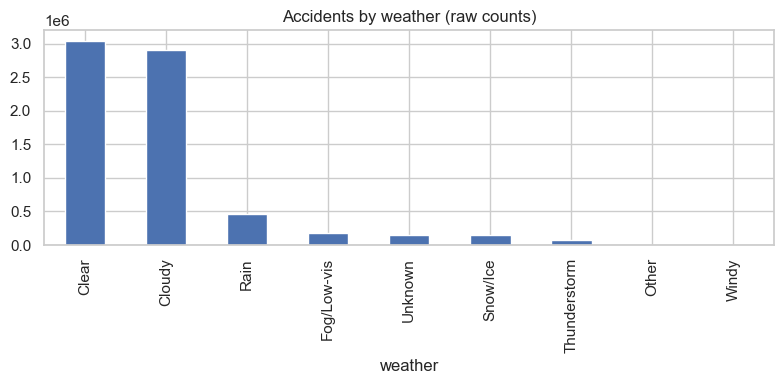

>> NOTE: raw counts peak in Clear/Cloudy because most driving happens in good weather. We therefore study SEVERITY (exposure-free) for the weather effect — next cell.


In [6]:
# 5. EDA
fig, ax = plt.subplots(2,2, figsize=(14,9))
df.groupby('ym').size().plot(ax=ax[0,0]); ax[0,0].set_title('Accidents per month'); ax[0,0].set_xlabel('')
df.groupby('hour').size().plot(kind='bar', ax=ax[0,1]); ax[0,1].set_title('Accidents by hour')
df['State'].value_counts().head(15).plot(kind='bar', ax=ax[1,0]); ax[1,0].set_title('Top 15 states (raw)')
df['Severity'].value_counts().sort_index().plot(kind='bar', ax=ax[1,1]); ax[1,1].set_title('Severity distribution')
plt.tight_layout(); plt.savefig('figs/eda_overview.png', dpi=120); plt.show()

plt.figure(figsize=(8,4)); df['weather'].value_counts().plot(kind='bar')
plt.title('Accidents by weather (raw counts)'); plt.tight_layout()
plt.savefig('figs/weather_counts.png', dpi=120); plt.show()
print(">> NOTE: raw counts peak in Clear/Cloudy because most driving happens in good weather. "
      "We therefore study SEVERITY (exposure-free) for the weather effect — next cell.")

               mean    count
weather                     
Rain          2.270   466748
Snow/Ice      2.265   155237
Cloudy        2.251  2899282
Thunderstorm  2.247    77545
Clear         2.200  3044607
Fog/Low-vis   2.192   182997


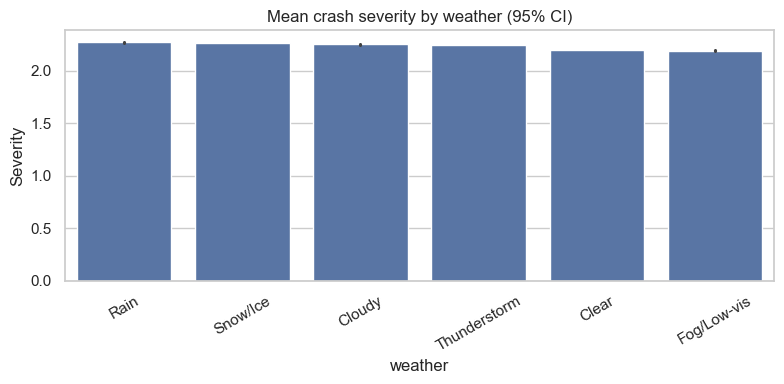

>> REPORT NUMBER chi2=32,916.0 dof=15 p=0.00e+00 CramersV=0.040 n=6,826,416
>> REPORT NUMBER Kruskal H=26,281.8 p=0.00e+00
>> REPORT NUMBER highest mean severity: Rain = 2.27


In [7]:
# 6. Statistical analysis: weather vs crash SEVERITY 
keep = ['Clear','Cloudy','Rain','Snow/Ice','Fog/Low-vis','Thunderstorm']
sub = df[df['weather'].isin(keep)].copy()

sev = sub.groupby('weather')['Severity'].agg(['mean','count']).sort_values('mean', ascending=False)
print(sev.round(3))
plt.figure(figsize=(8,4))
sns.barplot(data=sub, x='weather', y='Severity', errorbar=('ci',95), order=sev.index)
plt.title('Mean crash severity by weather (95% CI)'); plt.xticks(rotation=30)
plt.tight_layout(); plt.savefig('figs/severity_by_weather.png', dpi=120); plt.show()

ct = pd.crosstab(sub['weather'], sub['Severity'])
chi2, p, dof, _ = stats.chi2_contingency(ct)
n = ct.values.sum(); V = np.sqrt(chi2/(n*(min(ct.shape)-1)))
print(f">> REPORT NUMBER chi2={chi2:,.1f} dof={dof} p={p:.2e} CramersV={V:.3f} n={n:,}")
H, pk = stats.kruskal(*[g['Severity'].values for _,g in sub.groupby('weather')])
print(f">> REPORT NUMBER Kruskal H={H:,.1f} p={pk:.2e}")
print(">> REPORT NUMBER highest mean severity:", sev.index[0], "=", round(sev['mean'].iloc[0],3))

Text(0.5, 1.0, 'Mean crash severity by weather (y-axis zoomed to 2.15–2.29)')

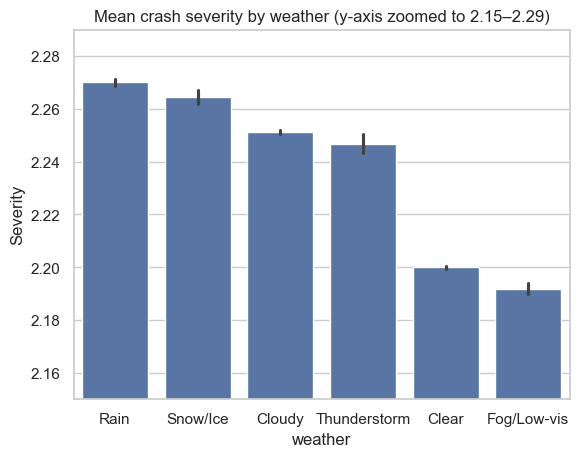

In [8]:
ax = sns.barplot(data=sub, x='weather', y='Severity', errorbar=('ci',95), order=sev.index)
ax.set_ylim(2.15, 2.29)   # zoom so the 0.08 spread is visible
plt.title('Mean crash severity by weather (y-axis zoomed to 2.15–2.29)')

In [9]:
# 7. Per-capita normalization by state + choropleth (fixes 'big states have more crashes')
state_pop = {'CA':38965000,'TX':30503000,'FL':22610000,'NY':19571000,'PA':12961000,'IL':12549000,
'OH':11785000,'GA':11029000,'NC':10835000,'MI':10037000,'NJ':9290000,'VA':8715000,'WA':7812000,
'AZ':7431000,'TN':7126000,'MA':7001000,'IN':6862000,'MO':6196000,'MD':6180000,'WI':5910000,
'CO':5877000,'MN':5737000,'SC':5373000,'AL':5108000,'LA':4574000,'KY':4526000,'OR':4233000,
'OK':4053000,'CT':3617000,'UT':3417000,'IA':3207000,'NV':3194000,'AR':3068000,'MS':2940000,
'KS':2941000,'NM':2114000,'NE':1978000,'ID':1965000,'WV':1770000,'HI':1435000,'NH':1402000,
'ME':1395000,'RI':1095000,'MT':1132000,'DE':1032000,'SD':919000,'ND':783000,'AK':733000,
'VT':647000,'WY':584000,'DC':678000}
region = {}
for r,sts in {'Northeast':'CT ME MA NH RI VT NJ NY PA','Midwest':'IL IN MI OH WI IA KS MN MO NE ND SD',
              'South':'DE FL GA MD NC SC VA DC WV AL KY MS TN AR LA OK TX',
              'West':'AZ CO ID MT NV NM UT WY AK CA HI OR WA'}.items():
    for s in sts.split(): region[s]=r

st = df.groupby('State').size().rename('accidents').reset_index()
st['pop'] = st['State'].map(state_pop); st = st.dropna(subset=['pop'])
st['per_100k'] = st['accidents']/st['pop']*1e5
st['region'] = st['State'].map(region)
print("Top 12 states by per-capita accident index:")
print(st.sort_values('per_100k', ascending=False).head(12)[['State','per_100k','region']].round(1).to_string(index=False))
print(">> REPORT NUMBER highest per-capita state:", st.sort_values('per_100k').iloc[-1]['State'])

try:
    import plotly.express as px
    fm = px.choropleth(st, locations='State', locationmode='USA-states', color='per_100k',
                       scope='usa', color_continuous_scale='OrRd',
                       title='Recorded accidents per 100k residents (relative index)')
    fm.write_html('figs/choropleth.html')
    try: fm.write_image('figs/choropleth.png', scale=2)
    except Exception as e: print('choropleth PNG skipped:', e)
    fm.show()
except Exception as e:
    print('choropleth skipped:', e)

Top 12 states by per-capita accident index:
State  per_100k  region
   SC    6533.3   South
   CA    4021.9    West
   OR    3846.2    West
   FL    3386.2   South
   VA    3002.2   South
   MN    2996.1 Midwest
   LA    2968.9   South
   NC    2859.9   South
   UT    2617.7    West
   DC    2323.9   South
   TN    2131.6   South
   AZ    2072.3    West
>> REPORT NUMBER highest per-capita state: SC


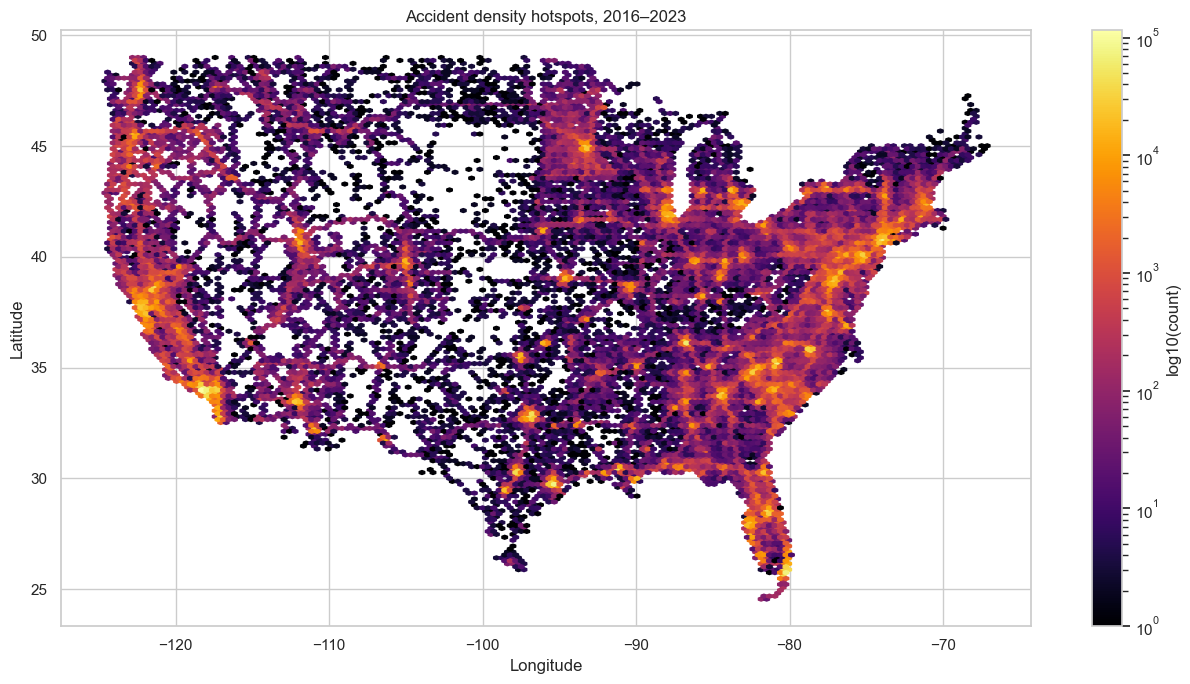

In [10]:
# 8. Geospatial: accident density hotspots (continental US)
m = df.dropna(subset=['Start_Lat','Start_Lng'])
m = m[(m['Start_Lng']>-125)&(m['Start_Lng']<-66)&(m['Start_Lat']>24)&(m['Start_Lat']<50)]
plt.figure(figsize=(13,7))
hb = plt.hexbin(m['Start_Lng'], m['Start_Lat'], gridsize=160, cmap='inferno', mincnt=1, bins='log')
plt.colorbar(hb, label='log10(count)'); plt.title('Accident density hotspots, 2016–2023')
plt.xlabel('Longitude'); plt.ylabel('Latitude')
plt.tight_layout(); plt.savefig('figs/density_hexbin.png', dpi=130); plt.show()

In [11]:
# 9. Predictive: monthly accident counts per state (exposure handled by log-pop offset)
panel = df.groupby(['State','year','month']).size().rename('count').reset_index()
panel = panel[panel['State'].isin(state_pop)]
panel['pop'] = panel['State'].map(state_pop)
panel['region'] = panel['State'].map(region)
panel['t'] = (panel['year']-panel['year'].min())*12 + panel['month']
cut = panel['t'].max()-6
train, test = panel[panel['t']<=cut].copy(), panel[panel['t']>cut].copy()

f = "count ~ C(month) + C(region)"
pois = smf.glm(f, data=train, family=sm.families.Poisson(), offset=np.log(train['pop'])).fit()
disp = pois.pearson_chi2/pois.df_resid
print(f">> REPORT NUMBER Poisson pseudoR2={1-pois.deviance/pois.null_deviance:.3f} dispersion={disp:.1f}")
nb = smf.glm(f, data=train, family=sm.families.NegativeBinomial(alpha=1.0), offset=np.log(train['pop'])).fit()
print(f">> REPORT NUMBER NegBin pseudoR2={1-nb.deviance/nb.null_deviance:.3f}")
for name,mod in [('Poisson',pois),('NegBin',nb)]:
    pred = mod.predict(test, offset=np.log(test['pop']))
    mae=np.mean(np.abs(pred-test['count'])); rmse=np.sqrt(np.mean((pred-test['count'])**2))
    print(f">> REPORT NUMBER {name} test MAE={mae:,.0f} RMSE={rmse:,.0f}")
irr = np.exp(pois.params.filter(like='C(month)'))
print(">> REPORT NUMBER peak-season month (highest IRR):", irr.idxmax(), "IRR=", round(irr.max(),2))

>> REPORT NUMBER Poisson pseudoR2=0.197 dispersion=954.0
>> REPORT NUMBER NegBin pseudoR2=0.085
>> REPORT NUMBER Poisson test MAE=1,201 RMSE=1,961
>> REPORT NUMBER NegBin test MAE=1,159 RMSE=2,291
>> REPORT NUMBER peak-season month (highest IRR): C(month)[T.12] IRR= 1.16


In [ ]:
# 11. Figures saved (download figs/ for the report)
# import os
# for f in sorted(os.listdir('figs')): print('figs/'+f)